# bootstrap confidence interval

In [12]:
import numpy as np
from pathlib import Path

# Set random seed (add this line)
np.random.seed(42)

# set up folder paths
base_path = Path('..')
################## User Inputs ############################## 
data = np.loadtxt(base_path/'results'/'summary'/'Mw_exceedance1.5_fault0_seed0-7.csv', delimiter=',', skiprows=1, dtype=float)
# Bootstrap parameters
n_boot = 10000
boot_means = []
################## End of User Inputs #######################

# Bootstrap resampling
for _ in range(n_boot):
    sample = np.random.choice(data, size=len(data), replace=True)
    boot_means.append(np.mean(sample))

boot_means = np.array(boot_means)

# Confidence interval (percentile method)
lower = np.percentile(boot_means, 2.5)
upper = np.percentile(boot_means, 97.5)

print("Data Mean:", np.mean(data))
print("Bootstrap Mean Estimate:", np.mean(boot_means))
print("95% Confidence Interval:", (lower, upper))

Data Mean: 0.0007546006466512702
Bootstrap Mean Estimate: 0.0007533974172748268
95% Confidence Interval: (0.0005649827857967667, 0.0009819299266743647)


In [13]:
data_var = np.var(data)
print(f'variance = {data_var}')
epsilon = 0.5*0.0007
alpha = 0.05
n_sample = data_var/(epsilon**2)/alpha
n_sample

variance = 4.7777475479363016e-06


780.0404159896002

# bootstrap confidence interval on a folder

In [44]:
import numpy as np
import pandas as pd
from pathlib import Path

# Set random seed
np.random.seed(42)

################## User Inputs ############################## 
n_boot = 100000
n_samples = []
ci_means = []
ci_lowers = []
ci_uppers = []
file_names = []
################## End of User Inputs #######################

# 1. Define the directory path
folder_path = Path('../results/summary/Mw_exceedance1.5_fault0')

# 2. Iterate through ALL .csv files, SORTED by name
# sorted() converts the generator to a sorted list
for csv_file in sorted(folder_path.glob('*.csv')):
    
    # 3. Load the data
    data = np.loadtxt(csv_file, delimiter=',', skiprows=1, dtype=float, ndmin=1)
    
    if data.size == 0:
        print(f"Skipping {csv_file.name}: File is empty.")
        continue

    print(f"Processing {csv_file.name}...")
    n_samples.append(len(data))

    # 4. Vectorized Bootstrap Resampling
    # Generate all bootstrap samples in one large matrix
    samples = np.random.choice(data, size=(n_boot, len(data)), replace=True)
    
    # Calculate the mean of each bootstrap sample (along columns)
    boot_array = np.mean(samples, axis=1)

    # 5. Calculate Statistics (Percentile Method)
    lower = np.percentile(boot_array, 2.5)
    upper = np.percentile(boot_array, 97.5)

    # Store results in lists
    file_names.append(csv_file.name)
    ci_means.append(np.mean(boot_array))
    ci_lowers.append(lower)
    ci_uppers.append(upper)

# 6. Create Results DataFrame
df_ci = pd.DataFrame({
    'File': file_names,
    'n_samples': n_samples,
    'Bootstrap_Mean': ci_means,
    'CI_Lower': ci_lowers,
    'CI_Upper': ci_uppers,
    'CI_half_width': (np.array(ci_uppers) - np.array(ci_lowers)) / 2
})

df_ci

Processing Mw_exceedance1.5_fault0_seed0-1.csv...
Processing Mw_exceedance1.5_fault0_seed0-3.csv...
Processing Mw_exceedance1.5_fault0_seed0-5.csv...
Processing Mw_exceedance1.5_fault0_seed0-6.csv...
Processing Mw_exceedance1.5_fault0_seed0-7.csv...


,File,n_samples,Bootstrap_Mean,CI_Lower,CI_Upper,CI_half_width
0,Mw_exceedance1.5_fault0_seed0-1.csv,90,0.000862,0.000447,0.001461,0.000507
1,Mw_exceedance1.5_fault0_seed0-3.csv,171,0.000807,0.000537,0.001152,0.000307
2,Mw_exceedance1.5_fault0_seed0-5.csv,257,0.000717,0.000499,0.000982,0.000242
3,Mw_exceedance1.5_fault0_seed0-6.csv,350,0.000660,0.000489,0.000862,0.000187
4,Mw_exceedance1.5_fault0_seed0-7.csv,433,0.000755,0.000567,0.000979,0.000206


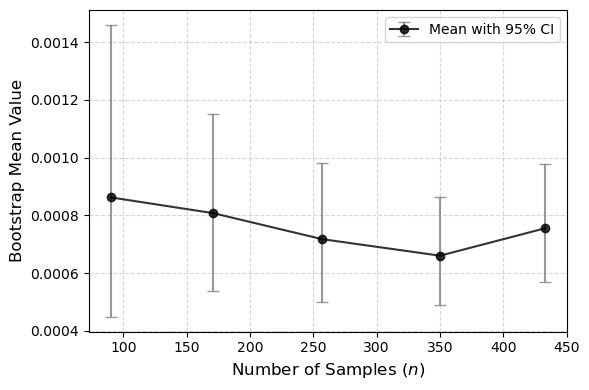

In [ ]:
import matplotlib.pyplot as plt

# 1. Sort by n_samples to ensure the plot flows correctly
df_plot = df_ci.sort_values('n_samples')

# 2. Calculate the magnitude of the errors
yerr_lower = df_plot['Bootstrap_Mean'] - df_plot['CI_Lower']
yerr_upper = df_plot['CI_Upper'] - df_plot['Bootstrap_Mean']
asymmetric_error = [yerr_lower, yerr_upper]

# 3. Create the plot
plt.figure(figsize=(6, 4))

plt.errorbar(
    df_plot['n_samples'], 
    df_plot['Bootstrap_Mean'], 
    yerr=asymmetric_error, 
    fmt='o',             # Circle markers
    color='black',   # Point color
    ecolor='gray', # Error bar color
    capsize=4,           # Cap width
    linestyle='-',       # Optional: connects points with a line to show trend
    alpha=0.8,
    label='Mean with 95% CI'
)

# 4. Formatting
# plt.title('Confidence Interval Convergence vs. Sample Size', fontsize=14)
plt.xlabel('Number of Samples ($n$)', fontsize=12)
plt.ylabel('Bootstrap Mean Value', fontsize=12)

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()



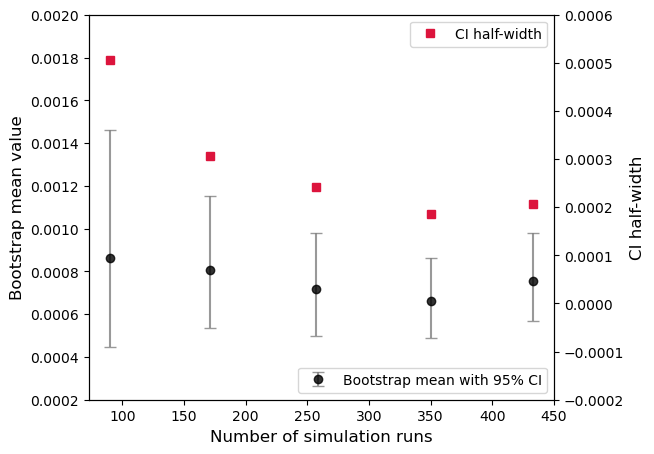

In [76]:
import matplotlib.pyplot as plt

# 1. Sort by n_samples to ensure the plot flows correctly
df_plot = df_ci.sort_values('n_samples')

# 2. Calculate the magnitude of the errors
yerr_lower = df_plot['Bootstrap_Mean'] - df_plot['CI_Lower']
yerr_upper = df_plot['CI_Upper'] - df_plot['Bootstrap_Mean']
asymmetric_error = [yerr_lower, yerr_upper]

# 3. Create the plot
fig, ax1 = plt.subplots(figsize=(6, 5))

ax1.errorbar(
    df_plot['n_samples'], 
    df_plot['Bootstrap_Mean'], 
    yerr=asymmetric_error, 
    fmt='o',             # Circle markers
    color='black',   # Point color
    ecolor='gray', # Error bar color
    capsize=4,           # Cap width
    # linestyle='-',       # Optional: connects points with a line to show trend
    alpha=0.8,
    label='Bootstrap mean with 95% CI'
)

# 4. Formatting
ax1.set_xlabel('Number of simulation runs', fontsize=12)
ax1.set_ylabel('Bootstrap mean value', fontsize=12)
# ax1.grid(True, which='both', linestyle='--', alpha=0.5)
ax1.legend(loc='lower right')
ax1.set_ylim(0.0002, 0.002)  # Set y-axis lower limit to 0 for better visualization


ax2 = ax1.twinx()  # Create a second y-axis sharing the same x-axis
ax2.plot(df_plot['n_samples'], df_plot['CI_half_width'], 's', color='crimson', label='CI half-width')
ax2.set_ylabel('CI half-width', fontsize=12)
ax2.set_ylim(-0.0002, 0.0006)
ax2.legend(loc='upper right')

fig.savefig('../results/summary/Mw_exceedance1.5_fault0/bootstrap_ci_convergence.png', dpi=300, bbox_inches='tight')

plt.show()

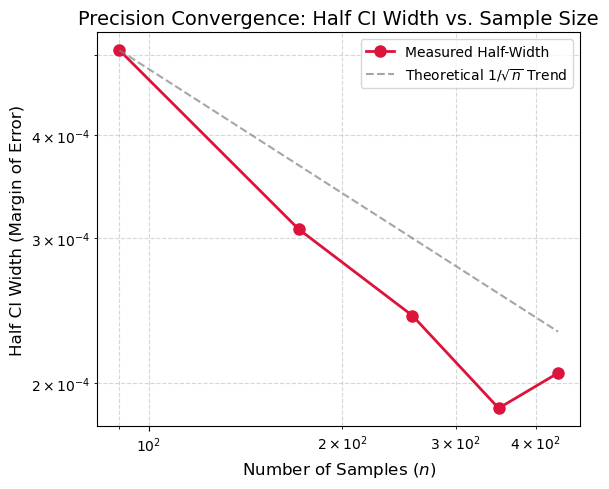

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate the Half-Width
# (Upper Bound - Lower Bound) / 2
df_ci['Half_Width'] = (df_ci['CI_Upper'] - df_ci['CI_Lower']) / 2

# 2. Sort by n_samples for a logical line plot
df_plot = df_ci.sort_values('n_samples')

# 3. Create the Plot
plt.figure(figsize=(6, 5))

# Plot the actual data
plt.plot(df_plot['n_samples'], df_plot['Half_Width'], 'o-', 
         markersize=8, color='crimson', linewidth=2, label='Measured Half-Width')

# 4. Optional: Add a theoretical 1/sqrt(n) reference line
# We anchor the theoretical curve to your first data point to show the slope
n_range = np.linspace(df_plot['n_samples'].min(), df_plot['n_samples'].max(), 100)
theoretical_slope = df_plot['Half_Width'].iloc[0] * (np.sqrt(df_plot['n_samples'].iloc[0]) / np.sqrt(n_range))
plt.plot(n_range, theoretical_slope, '--', color='gray', alpha=0.7, label=r'Theoretical $1/\sqrt{n}$ Trend')

# 5. Formatting
plt.title('Precision Convergence: Half CI Width vs. Sample Size', fontsize=14)
plt.xlabel('Number of Samples ($n$)', fontsize=12)
plt.ylabel('Half CI Width (Margin of Error)', fontsize=12)

# Use Log-Log scale to see the power-law relationship clearly
plt.xscale('log')
plt.yscale('log')

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()